In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns


from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


pd.set_option("display.max_colwidth", None)
RANDOM_STATE = 42

C:\Users\Admin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
dataset = load_dataset("papluca/language-identification")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['labels', 'text'],
        num_rows: 70000
    })
    validation: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
    test: Dataset({
        features: ['labels', 'text'],
        num_rows: 10000
    })
})


In [4]:
train_df = pd.DataFrame(dataset["train"]).sample(10000)
test_df = pd.DataFrame(dataset["test"])

In [5]:
print("Train Shape:", train_df.shape)
print("Test Shape :", test_df.shape)

Train Shape: (10000, 2)
Test Shape : (10000, 2)


In [6]:
train_df.head()

,labels,text
41095,ur,اس وجہ سے کہ ہر کسی کو قتل نہیں کیا جا سکتا ہے ، لیکن بچوں کے لئے ایک سال سے کم عرصہ قبل
24455,ru,"На мосту baggot-стрит вы найдете штаб-офис "" Bord Ф Ilte ( ирландский туристический совет ) ."
60510,tr,Ve bir sürü kötü şey var . Bunu izlemek bile beni depresyona giriyor .
66173,de,Falscher Artikel wurde geschickt und ich muss jetzt einen dpd Laden suchen. Lächerlich
53910,it,Il presidente dell'Ecuador Correa dice che non è stata presa alcuna decisione sull'asilo di Assange


In [7]:
train_df.isnull().sum()

,0
labels,0
text,0


In [8]:
train_df.duplicated().sum()

np.int64(33)

In [9]:
train_df["labels"].nunique()

20

In [10]:
train_df["labels"].value_counts()

,count
labels,
bg,522
tr,521
sw,517
it,516
pt,511
vi,510
el,510
ja,510
en,504


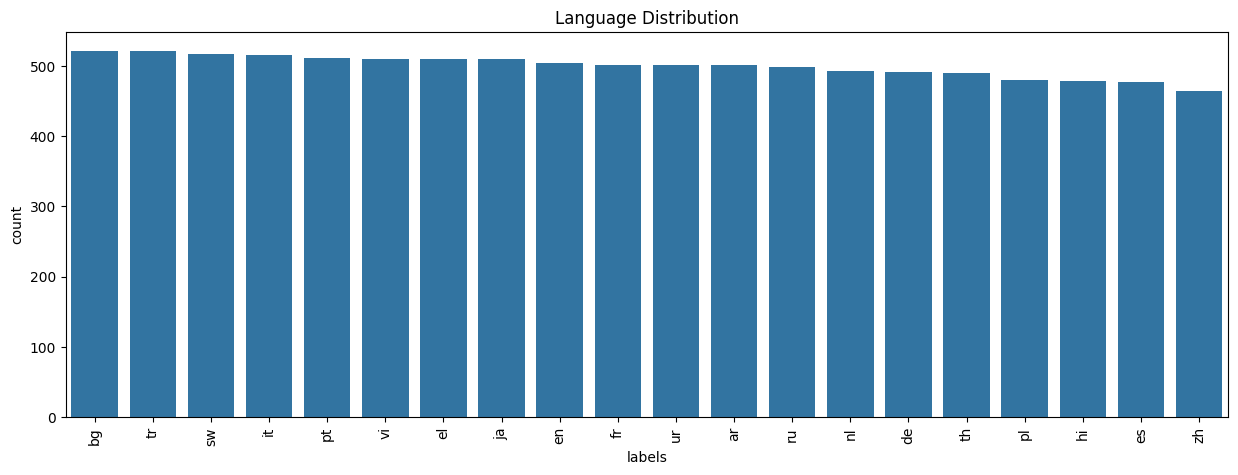

In [11]:
plt.figure(figsize=(15,5))

sns.countplot(
    data=train_df,
    x="labels",
    order=train_df["labels"].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Language Distribution")

plt.show()

In [12]:
duplicates_count = train_df.duplicated().sum()
duplicates_percentage = (duplicates_count / len(train_df)) * 100
print("Duplicates:", duplicates_count)
print("Percentage:", round(duplicates_percentage,2), "%")

Duplicates: 33
Percentage: 0.33 %


In [13]:
train_df[train_df.duplicated(keep=False)].sort_values("text").head(20)

,labels,text
6776,es,Cumple con las expectativas
33214,es,Cumple con las expectativas
66759,pl,Człowiek gra na gitarze.
64773,pl,Człowiek gra na gitarze.
36728,pl,Człowiek gra na gitarze.
59640,nl,Een hond die zwemt met een stok in zijn bek.
64605,nl,Een hond die zwemt met een stok in zijn bek.
60307,nl,Een man speelt gitaar.
46212,nl,Een man speelt gitaar.
22115,nl,Een man speelt piano.


In [14]:
train_df = train_df.drop_duplicates()

In [15]:
train_df["text_length"] = train_df["text"].apply(len)

In [16]:
train_df["text_length"].describe()

,text_length
count,9967.000000
mean,110.211498
std,100.970055
min,3.000000
25%,46.000000
50%,81.000000
75%,143.000000
max,2001.000000


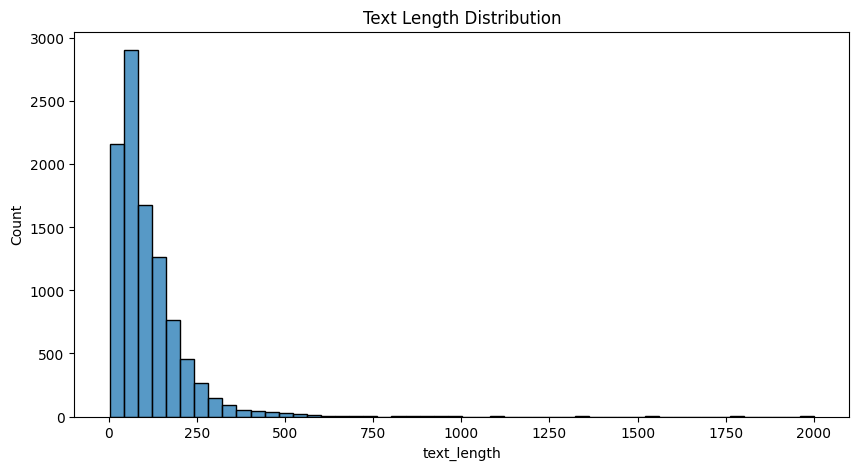

In [17]:
plt.figure(figsize=(10,5))
sns.histplot(train_df["text_length"],bins=50)
plt.title("Text Length Distribution")
plt.show()

In [18]:
print("Shortest")
display(train_df.nsmallest( 10, "text_length"))

Shortest


,labels,text,text_length
52213,ur,گھر,3
36651,ur,پیجر,4
62064,ru,Район,5
54901,sw,Awe .,5
59487,ur,اوہ وہ,6
570,ur,وولف .,6
7525,sw,Yakua ?,7
14557,tr,Yudum .,7
32124,tr,# isim ?,8
57223,ur,تھوڑے سے,8


In [19]:
print("Longest")
display(train_df.nlargest(10, "text_length"))

Longest


,labels,text,text_length
39287,de,"Vorab, diese Rezension basiert auf meiner persönlichen Erfahrung mit dem Stick und kann daher von anderen Meinungen und Erfahrungen abweichen: Ich habe mir den Stick gekauft, da ich einen schnellen und recht großen (Speichergröße) Stick gesucht habe. Im Grunde war ich bei der super schnellen Lieferung vom Design und der kompakten Größe sehr angetan. Der Stick schaut wirklich chick aus und wirkt durchaus wertig. Was mir nicht gut gefallen hat und mich zum ABER bzw. 2 Sternen Abwertung bringt sind folgende Dinge: * USB 3.1 steht in der Beschreibung ABER am 3.1 HUB wird der Stick nicht erkannt... muss man erst ein Firmwareupdate oder soetwas für den Stick durchführen???? Ich kann es nicht sagen, da ich mich mit soetwas einfach nicht beschäftigt habe, bei einem 3.1 Stick gehe ich von 3.1 Unterstützung aus... * Geschwindigkeit: Klar habe ich nicht mit 200 MB/s schreiben gerechnet aber etwas mehr als 30 MB/s hätten es ruhig sein dürfen... ein Freund von mir hat einen anderen 3.1 Stick und der hat eine deutlich höhere Leistung beim schreiben gezeigt. Bitte versteht mich nicht falsch, 30 MB/s sind auch schon ganz ok (besonders, wenn es Rezensionen gibt wo bei anderen Sticks von unter 10 MB/s geschrieben wird) ABER irgendwie passt das einfach nicht zum ""Design"" und der Beschreibung... Mein persönliches Fazit: Der Stick geht nicht zurück, da ich auch mit den beschriebenen Einschränkungen und 30 MB/s leben kann ABER beim nächsten kauf werde ich wahrscheinlich den anderen Hersteller eine Chance geben, da ich bei einer noch größeren Größe gerne auch ein etwas höheres Tempo hätte :) Vielleicht habe ich auch ein Montags-Stick erwischt... daher: Der Stick ist schon cool, halt ggf. mit Einschränkungen (falls man auch ein Montags-Stick bekommt). Jeder der einen kleinen USB Stick mit einer großen Speichermenge sucht und nicht unbedingt eine hohe Geschwindigkeit benötigt (wobei das vielleicht bei anderen Generationen besser ist) kann sich den Kauf meiner Meinung nach durchaus überlegen.",2001
52943,en,"UPDATE: I was able to get a replacement for the set. But Amazon return process was just short of a nightmare. I had to call amazon 4 times to get everything picked up. They kept only providing 1 return slip for all 5 boxes and kept telling me it was ok. However, UPS wanted 5 unique return slips for each box. I took off of work to be home for the pickup appointment time, but UPS was never notified the first time. So I took off of work and sat home for nothing. I'm still happy with my purchase and really like the set. EDIT: Firepit no longer works, stays lit for 3 minutes then fades out. It appears to be an issue with the dial What I like: Everything was delivered in 3 days and none of the boxes were destroyed. Everything was easy to put together. The chairs seem to be well made, I like how the 2 cushions velcro together to stay in place. The firepit look nice, maybe a little more attention to detail could have been used. But that's just nitpicking. I like how the firepit and side table/tank holder have adjustable feet to make level. What I didn't like: I had serious issues trying to get the fire pit to light. At first I thought I had too much lava rocks, so I removed all. Then I thought I had an issue with my tank and swapped it with my grill tank to be sure. Then I thought I had an issue with the propane gas line connections. Then I thought I had issues with the dial on the firepit. Apparently you have to press the dial in once you turn it to on, then hit the lighter. I was just turning the dial on and clicking the lighter and nothing was happening. I also don't like that it's $60 cheaper today than when I purchased it 3 days ago. In summary, I'm happy with my purchase. And I'm glad that I also purchased covers for everything as to keep it from sun fading.",1786
15662,en,"I enjoyed the form function of my new Samsung Note 9 so much that I refused to get a protective case. However, that phone is so slippery that 

In [20]:
sample_languages = [
    "ar",
    "en",
    "fr",
    "de",
    "es",
    "ru",
    "zh"
]
for lang in sample_languages:
    print("\n" + "=" * 100)
    print(f"Language: {lang}")
    print("=" * 100)
    samples = train_df[train_df["labels"] == lang]["text"].sample(5, random_state=42)
    for i, text in enumerate(samples, 1):
        print(f"\nSample {i}:")
        print(text[:300])


Language: ar

Sample 1:
نظام نظام المدارس العامة يبدو انه يحصل على الكثير من النقد مؤخرا اعتقد على مر السنين انه دائما يبدو اسوا بالنسبة للاباء الذين لديهم اطفال هناك اكثر مما كان عندما كانوا هناك لذا انا لا اعرف كم هو جيد الكثير منها يستحق ولكن بعد ذلك الكثير منها ليس انا اعني ان الاطفال ياتون لتعلم الاشياء بسرعة اكبر لكي

Sample 2:
2001-وفي نيسان / ابريل 2001 , وبعد الفترة المشمولة بالتقرير مباشرة , عقد الفقر مؤتمرا لمدة ثلاثة ايام في هيرشي , بنسلفانيا , بعنوان " انشاء مجتمعات حكومية تابعة للعدالة

Sample 3:
( في ) -- ( بوب ليفينغستون ) , ( هايلي باربر ) , ( تومي بوغز ) -- هم الاكثر نجاحا في ( واشنطن )

Sample 4:
اذا حاول ان بلوك او باري مع العصي المتفحمة , فانهم سوف تنكسر .

Sample 5:
نعم حسنا يقولون ان عملية الايض لديك تبطئ مع ستة بالمائة مع كل عشر سنوات من حياتك او شيء من هذا القبيل

Language: en

Sample 1:
They stopped working in 1 month. I am very disappointed.

Sample 2:
I enjoy watching this channel.

Sample 3:
Character s not very well developed

Sample 4:
Nice little hand b

In [21]:
for lang in sample_languages:
    print("\n" + "=" * 100)
    print(f"Language: {lang}")
    print("=" * 100)
    temp = train_df[train_df["labels"] == lang].copy()
    temp["length"] = temp["text"].str.len()
    longest = temp.nlargest(3, "length")
    for _, row in longest.iterrows():

        print(f"\nLength = {row['length']}")
        print(row["text"][:500])
        print("-" * 50)


Language: ar

Length = 590
باستثناء bullmore فظيع المروعة ( لهجتها مثير للش مثير للش مثير للش مثير للش مثير للشهية ) , بقية الممثلين هم مايكل كيتشن مثل بيتر والش القديم , الذي عقلي تماما مع الان كوكس , الشاب والش , الذي كنت اتساءل اذا كان gorris قد حصلت على عقد من الة زمن واستخدمت نفس الممثل مرتين ؛ و التبشيريةلينا cadell التبشيرية انسة انسة ؛ ؛ سارة badel ' و ساطع السيدة rosseter ( سالي سيتون ) ؛ اوليفر فورد ديفيس احمق هيو whitbread ؛ جون ستاند ' وقد استقر بقلق دالاواي الاكبر سنا ؛ والسيدة احمق الحمقاء بروتون من مارغريت 
--------------------------------------------------

Length = 491
وتختلف هذه الخدمات بوجه عام عن عمليات مراجعة الحسابات المالية , والالتزامات بالتصديق , ومراجعة الاداء في مراجعي الحسابات ( 1 ) التي تقدم معلومات او بيانات الى الطرف الطالب دون تقديم التحقق او التحليل او تقييم المعلومات او البيانات , وبالتالي فان العمل يقوم به . 2-لا يوفر عادة اساسا لاستنتاج او توصيات او اراء بشان المعلومات او البيانات , او ( 2 ) اداء المهام التي طلبتها الادارة والتي تدعم مباشرة عمليات ا

In [22]:
X_train = train_df["text"]
y_train = train_df["labels"]

X_test = test_df["text"]
y_test = test_df["labels"]

In [23]:
class TextPreprocessor(BaseEstimator, TransformerMixin):

    def __init__(
        self,
        lowercase=False,
        remove_extra_spaces=True,
        remove_numbers=False,
        remove_punctuation=False
    ):

        self.lowercase = lowercase
        self.remove_extra_spaces = remove_extra_spaces
        self.remove_numbers = remove_numbers
        self.remove_punctuation = remove_punctuation

    def fit(self, X, y=None):
        return self

    def transform(self, X):

        results = []

        for text in X:

            if self.lowercase:
                text = text.lower()

            if self.remove_numbers:
                text = re.sub(r"\d+", "", text)

            if self.remove_punctuation:
                text = re.sub(
                    r"[^\w\s]",
                    "",
                    text
                )

            if self.remove_extra_spaces:
                text = " ".join(text.split())

            results.append(text)

        return results

In [24]:
def evaluate_model(model, X_test, y_test):
    predictions = model.predict(X_test)
    accuracy = accuracy_score(y_test, predictions)
    print(f"Accuracy: {accuracy:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_test, predictions))
    return accuracy

In [42]:
pipeline_baseline = Pipeline([
    ("preprocessing", TextPreprocessor(lowercase=False, remove_numbers=False, remove_punctuation=False)),
    ("tfidf", TfidfVectorizer(analyzer='char', ngram_range=(1, 3))),
    ("classifier",LogisticRegression(max_iter=1000))
])

In [43]:
pipeline_baseline.fit(X_train,y_train)

Pipeline(steps=[('preprocessing', TextPreprocessor()),
                ('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(1, 3))),
                ('classifier', LogisticRegression(max_iter=1000))])

In [44]:
baseline_acc = evaluate_model(pipeline_baseline,X_test,y_test)

Accuracy: 0.9895

Classification Report:
              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       0.98      0.99      0.99       500
          de       1.00      0.99      0.99       500
          el       1.00      1.00      1.00       500
          en       1.00      1.00      1.00       500
          es       0.99      0.99      0.99       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.97      0.98       500
          it       0.99      0.97      0.98       500
          ja       1.00      1.00      1.00       500
          nl       0.99      0.99      0.99       500
          pl       0.99      0.99      0.99       500
          pt       0.96      0.98      0.97       500
          ru       0.99      0.98      0.98       500
          sw       0.93      0.99      0.96       500
          th       1.00      1.00      1.00       500
          tr       1.00      1.00      1

In [34]:
pipeline_lower = Pipeline([
    ("preprocessing", TextPreprocessor(lowercase=True)),
    ("tfidf", TfidfVectorizer(analyzer="char")),
    ("classifier",LogisticRegression(max_iter=1000))
])

In [35]:
pipeline_lower.fit(X_train, y_train)
lower_acc = evaluate_model(pipeline_lower, X_test, y_test)

Accuracy: 0.9452

Classification Report:
              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       0.91      0.98      0.94       500
          de       0.94      0.95      0.95       500
          el       1.00      1.00      1.00       500
          en       0.91      0.93      0.92       500
          es       0.84      0.89      0.86       500
          fr       0.91      0.93      0.92       500
          hi       1.00      0.97      0.98       500
          it       0.84      0.78      0.81       500
          ja       1.00      1.00      1.00       500
          nl       0.86      0.85      0.85       500
          pl       0.98      0.94      0.96       500
          pt       0.85      0.85      0.85       500
          ru       0.97      0.91      0.94       500
          sw       0.91      0.98      0.94       500
          th       1.00      1.00      1.00       500
          tr       0.99      0.99      0

In [36]:
pipeline_numbers = Pipeline([
    ("preprocessing", TextPreprocessor(lowercase=True, remove_numbers = True)),
    ("tfidf", TfidfVectorizer(analyzer="char")),
    ("classifier",LogisticRegression(max_iter=1000))
])

In [37]:
pipeline_numbers.fit(X_train, y_train)
numbers_acc = evaluate_model(pipeline_numbers, X_test, y_test)

Accuracy: 0.9450

Classification Report:
              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       0.91      0.98      0.94       500
          de       0.94      0.95      0.95       500
          el       1.00      1.00      1.00       500
          en       0.91      0.93      0.92       500
          es       0.83      0.89      0.86       500
          fr       0.91      0.93      0.92       500
          hi       1.00      0.97      0.98       500
          it       0.85      0.78      0.81       500
          ja       1.00      1.00      1.00       500
          nl       0.86      0.85      0.85       500
          pl       0.99      0.94      0.96       500
          pt       0.85      0.85      0.85       500
          ru       0.97      0.91      0.94       500
          sw       0.91      0.98      0.94       500
          th       1.00      1.00      1.00       500
          tr       0.99      0.99      0

In [38]:
pipeline_punctuation = Pipeline([
    ("preprocessing", TextPreprocessor(lowercase=True, remove_punctuation=True)),
    ("tfidf", TfidfVectorizer(analyzer="char")),
    ("classifier",LogisticRegression(max_iter=1000))
])

In [39]:
pipeline_punctuation.fit(X_train, y_train)
punctuation_acc = evaluate_model(pipeline_punctuation, X_test, y_test)

Accuracy: 0.9431

Classification Report:
              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       0.91      0.98      0.94       500
          de       0.94      0.95      0.94       500
          el       1.00      1.00      1.00       500
          en       0.91      0.92      0.91       500
          es       0.83      0.88      0.85       500
          fr       0.90      0.93      0.91       500
          hi       1.00      0.97      0.98       500
          it       0.83      0.77      0.80       500
          ja       1.00      1.00      1.00       500
          nl       0.86      0.84      0.85       500
          pl       0.99      0.94      0.96       500
          pt       0.86      0.85      0.85       500
          ru       0.97      0.91      0.94       500
          sw       0.90      0.98      0.94       500
          th       1.00      1.00      1.00       500
          tr       0.99      0.99      0

In [40]:
comparison_df = pd.DataFrame({
    "Experiment":[
        "Baseline",
        "Lowercase",
        "Lowercase + Numbers",
        "Lowercase + Punctuation"
    ],
    "Accuracy":[
        baseline_acc,
        lower_acc,
        numbers_acc,
        punctuation_acc
    ]
})

comparison_df.sort_values("Accuracy",ascending=False)

,Experiment,Accuracy
0,Baseline,0.9452
1,Lowercase,0.9452
2,Lowercase + Numbers,0.9450
3,Lowercase + Punctuation,0.9431


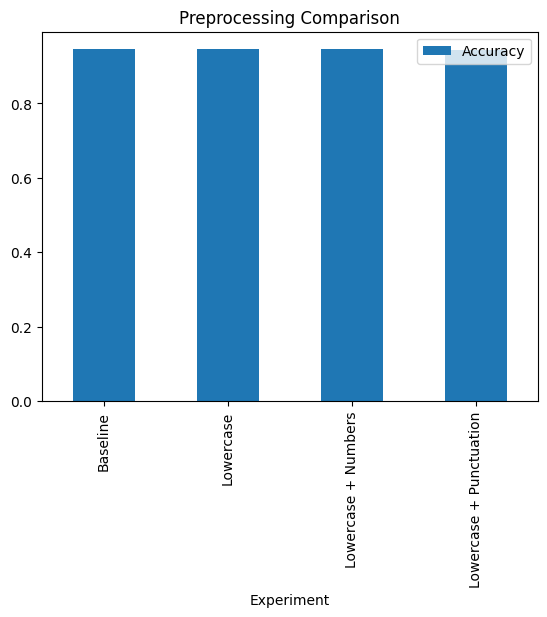

In [41]:
comparison_df.plot(x="Experiment", y="Accuracy", kind="bar")
plt.title("Preprocessing Comparison")
plt.show()

In [68]:
train_df = pd.DataFrame(dataset["train"])
X_train = train_df["text"]
y_train = train_df["labels"]

In [69]:
final_pipeline = Pipeline([
    ("tfidf",TfidfVectorizer(analyzer="char",ngram_range=(1,3))),
    ("classifier",LogisticRegression(max_iter=1000, random_state=42))
])

In [70]:
final_pipeline.fit(X_train, y_train)

Pipeline(steps=[('tfidf', TfidfVectorizer(analyzer='char', ngram_range=(1, 3))),
                ('classifier',
                 LogisticRegression(max_iter=1000, random_state=42))])

In [71]:
final_acc = evaluate_model(final_pipeline, X_test, y_test)

Accuracy: 0.9935

Classification Report:
              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       0.99      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       1.00      1.00      1.00       500
          es       0.99      0.99      0.99       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.97      0.98       500
          it       0.99      0.99      0.99       500
          ja       1.00      1.00      1.00       500
          nl       0.99      0.99      0.99       500
          pl       0.99      0.99      0.99       500
          pt       0.99      0.98      0.98       500
          ru       1.00      0.99      1.00       500
          sw       0.94      1.00      0.97       500
          th       1.00      1.00      1.00       500
          tr       1.00      1.00      1

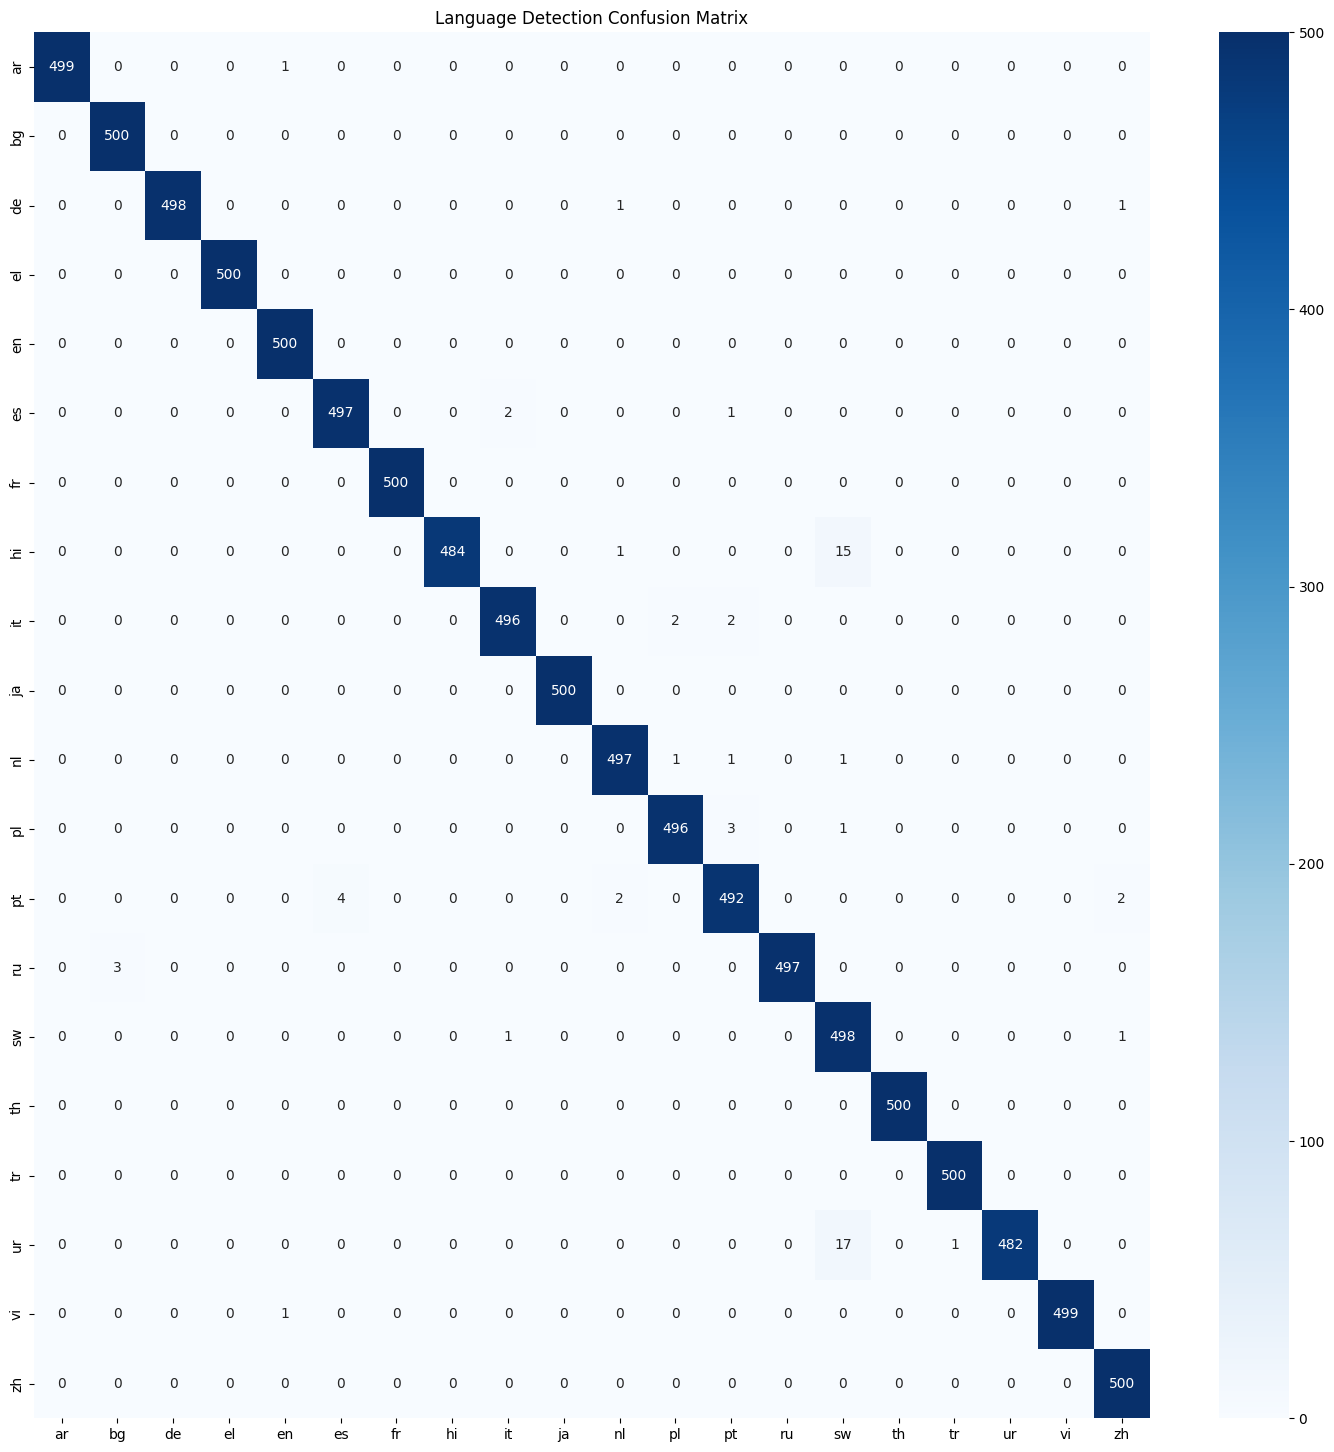

In [72]:
predictions = final_pipeline.predict(X_test)
class_names = {k:v for k,v in enumerate(final_pipeline.classes_)}
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(18,18))
sns.heatmap(cm, cmap="Blues", annot=True, fmt="d", xticklabels=list(class_names.values()), yticklabels=list(class_names.values()))
plt.title("Language Detection Confusion Matrix")
plt.show()

In [73]:
import joblib
joblib.dump(final_pipeline, "language_detector.pkl")

['language_detector.pkl']

In [74]:
import joblib

class LanguageDetector:
    def __init__(self):
        self.model = joblib.load("language_detector.pkl")
    def predict(self, text):
        text = " ".join(text.split())
        return self.model.predict([text])[0]

In [76]:
model = LanguageDetector()
model.predict('ازيكم عاملين اي')

'ar'

In [77]:
model.predict('Hello Every One (مرحب)')

'en'